# 01 - Train ATN (reface_atn.pth) — DirectML-Safe Edition

### Fixes applied vs previous version
| Fix | Reason |
|-----|--------|
| Batch size 16 → **4** (DirectML) | Skip-connection activations ÷4 |
| Surrogate kept on **CPU** | Removes ~100 MB constant VRAM resident |
| Embedding cache computed on **CPU** | Removes 97 MB spike per caching step |
| `shield_embed` computed on CPU, only vector moved to GPU | Second surrogate call no longer on GPU |
| Explicit `gc.collect()` before training | Releases Python refs before GPU work |
| Windows **TDR timeout** instructions added | Prevents driver reset on slow ops |

> **One-time Windows fix (run PowerShell as Administrator, then reboot):**
> ```powershell
> reg add "HKEY_LOCAL_MACHINE\System\CurrentControlSet\Control\GraphicsDrivers" /v TdrDelay /t REG_DWORD /d 60 /f
> reg add "HKEY_LOCAL_MACHINE\System\CurrentControlSet\Control\GraphicsDrivers" /v TdrDdiDelay /t REG_DWORD /d 60 /f
> ```

In [2]:
# Cell 1 - Imports & Config
import os
import gc
import math
import json
import time
import hashlib
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

from facenet_pytorch import InceptionResnetV1
from skimage.metrics import structural_similarity as ssim

try:
    import torch_directml
    HAS_DML = bool(torch_directml.is_available())
except Exception:
    torch_directml = None
    HAS_DML = False

ROOT           = Path(r'D:/deepfake_detection')
TRAIN_DIR      = ROOT / 'data' / 'atn_train'
VAL_DIR        = ROOT / 'data' / 'atn_val'
OUTPUT_PATH    = ROOT / 'models' / 'reface_atn.pth'
CHECKPOINT_DIR = ROOT / 'models' / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS   = 20
LR       = 1e-4
EPSILON  = 0.05
LAMBDA_X = 1.0
LAMBDA_Y = 10.0
IMG_SIZE = 224

# ── Device selection ──────────────────────────────────────────────────────
HAS_CUDA = torch.cuda.is_available()

if HAS_DML:
    DEVICE         = torch_directml.device()
    DEVICE_BACKEND = 'directml'
elif HAS_CUDA:
    DEVICE         = torch.device('cuda')
    DEVICE_BACKEND = 'cuda'
else:
    DEVICE         = torch.device('cpu')
    DEVICE_BACKEND = 'cpu'

# ── FIX 1: Reduced batch size for DirectML ────────────────────────────────
# Root cause of forced shutdown: at batch=16 the U-Net skip-connection
# activations alone can consume ~400 MB of shared VRAM on DirectML.
# Reducing to 4 brings that below ~100 MB.
if DEVICE_BACKEND == 'directml':
    BATCH_SIZE       = 4   # was 16 — critical fix
    MICRO_BATCH_SIZE = 1
elif DEVICE_BACKEND == 'cuda':
    BATCH_SIZE       = 64
    MICRO_BATCH_SIZE = BATCH_SIZE
else:
    BATCH_SIZE       = 8
    MICRO_BATCH_SIZE = BATCH_SIZE

USE_AMP      = DEVICE_BACKEND == 'cuda'
PIN_MEM      = DEVICE_BACKEND == 'cuda'
NON_BLOCKING = DEVICE_BACKEND == 'cuda'

if os.name == 'nt' and DEVICE_BACKEND != 'cuda':
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(2, os.cpu_count() or 1)

# ── FIX 2: Surrogate always lives on CPU ──────────────────────────────────
# Keeping InceptionResnetV1 (~100 MB) on DirectML simultaneously with the
# ATN was filling shared VRAM. Embeddings are tiny (512 floats) so moving
# only those vectors to the GPU is essentially free.
SURROGATE_DEVICE = torch.device('cpu')

print('PyTorch version  :', torch.__version__)
print('CUDA available   :', HAS_CUDA)
print('DirectML ready   :', HAS_DML)
print('ATN device       :', DEVICE, f'({DEVICE_BACKEND})')
print('Surrogate device :', SURROGATE_DEVICE, '← always CPU (memory fix)')
print('AMP enabled      :', USE_AMP)
print('num_workers      :', NUM_WORKERS)
print('Batch size       :', BATCH_SIZE, '← reduced from 16 (memory fix)')
print('Micro-batch size :', MICRO_BATCH_SIZE)
print('Train dir        :', TRAIN_DIR)
print('Val dir          :', VAL_DIR)
print('Output           :', OUTPUT_PATH)


PyTorch version  : 2.4.1+cpu
CUDA available   : False
DirectML ready   : True
ATN device       : privateuseone:0 (directml)
Surrogate device : cpu ← always CPU (memory fix)
AMP enabled      : False
num_workers      : 0
Batch size       : 4 ← reduced from 16 (memory fix)
Micro-batch size : 1
Train dir        : D:\deepfake_detection\data\atn_train
Val dir          : D:\deepfake_detection\data\atn_val
Output           : D:\deepfake_detection\models\reface_atn.pth


Total train images: 4000


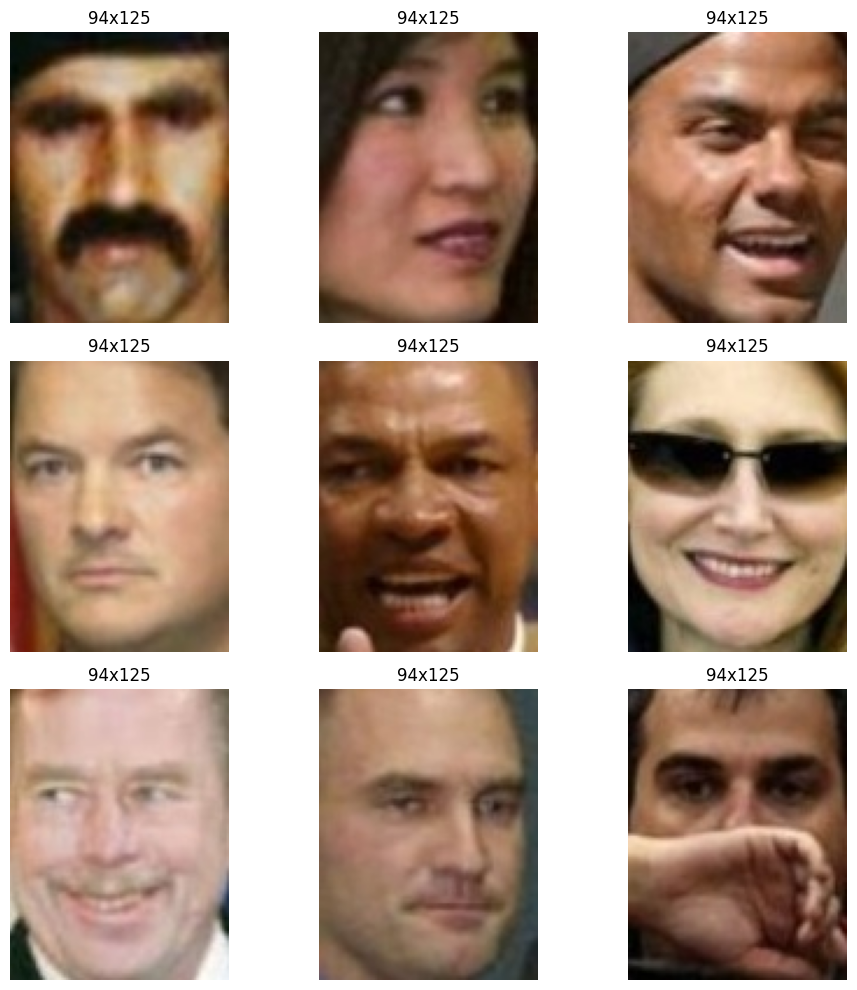

Mean pixel value (sample avg): 0.44457393884658813


In [3]:
# Cell 2 - Dataset Preview
def list_images(directory: Path):
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    return [p for p in directory.rglob('*') if p.suffix.lower() in exts]

train_images = list_images(TRAIN_DIR)
print('Total train images:', len(train_images))

sample_paths = train_images[:9]
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
means = []
for ax, p in zip(axes.flatten(), sample_paths):
    img = Image.open(p).convert('RGB')
    arr = np.asarray(img).astype(np.float32) / 255.0
    means.append(arr.mean())
    ax.imshow(arr)
    ax.set_title(f'{img.size[0]}x{img.size[1]}')
    ax.axis('off')

for ax in axes.flatten()[len(sample_paths):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

if means:
    print('Mean pixel value (sample avg):', float(np.mean(means)))
else:
    print('No images found in atn_train.')


In [4]:
# Cell 3 - Dataset & DataLoader
class FaceImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_images  = list_images(VAL_DIR)
train_ds    = FaceImageDataset(train_images, transform=train_tf)
val_ds      = FaceImageDataset(val_images,   transform=val_tf)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEM,
    shuffle=True,
    persistent_workers=False
)

train_loader = DataLoader(train_ds, **loader_kwargs)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEM,
                          persistent_workers=False)

print('Train dataset size  :', len(train_ds))
print('Val dataset size    :', len(val_ds))
print('Train batches/epoch :', len(train_loader))

_t0 = time.time()
_first_batch = next(iter(train_loader))
print('First batch shape   :', tuple(_first_batch.shape))
print('First batch load  s :', round(time.time() - _t0, 2))


Train dataset size  : 4000
Val dataset size    : 1000
Train batches/epoch : 1000
First batch shape   : (4, 3, 224, 224)
First batch load  s : 0.15


In [5]:
# Cell 4 - ATN Architecture (Residual U-Net)
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.bn2(self.conv2(x))
        return F.relu(x + identity, inplace=True)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            ResidualBlock(out_ch)
        )
    def forward(self, x):
        return self.conv(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.fuse = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            ResidualBlock(out_ch)
        )
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([x, skip], dim=1))

class ResidualUNetATN(nn.Module):
    def __init__(self, epsilon=0.05):
        super().__init__()
        self.epsilon    = epsilon
        self.stem       = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.down1      = DownBlock(64,  128)
        self.down2      = DownBlock(128, 256)
        self.down3      = DownBlock(256, 512)
        self.down4      = DownBlock(512, 512)
        self.bottleneck = nn.Sequential(ResidualBlock(512), ResidualBlock(512))
        self.up1        = UpBlock(512, 512, 512)
        self.up2        = UpBlock(512, 256, 256)
        self.up3        = UpBlock(256, 128, 128)
        self.up4        = UpBlock(128,  64,  64)
        self.out        = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, x):
        s0 = self.stem(x)
        s1 = self.down1(s0);  s2 = self.down2(s1)
        s3 = self.down3(s2);  s4 = self.down4(s3)
        b  = self.bottleneck(s4)
        d1 = self.up1(b,  s3); d2 = self.up2(d1, s2)
        d3 = self.up3(d2, s1); d4 = self.up4(d3, s0)
        p  = torch.tanh(self.out(d4))
        return torch.clamp(p, -self.epsilon, self.epsilon)

atn = ResidualUNetATN(epsilon=EPSILON).to(DEVICE)

total_params    = sum(p.numel() for p in atn.parameters())
trainable_params = sum(p.numel() for p in atn.parameters() if p.requires_grad)
print(f'ATN total params     : {total_params:,}')
print(f'ATN trainable params : {trainable_params:,}')
print(f'ATN device           : {next(atn.parameters()).device}')


ATN total params     : 38,549,827
ATN trainable params : 38,549,827
ATN device           : privateuseone:0


In [6]:
# Cell 5 - Surrogate Face Recognition Model
# ── FIX: Surrogate stays on CPU ──────────────────────────────────────────
# Previously: surrogate.to(DEVICE) — put ~100 MB on DirectML alongside ATN.
# Now:        surrogate.to(SURROGATE_DEVICE) — always CPU.
#
# Why this is safe:
#   - Surrogate is frozen (no gradients), so it never needs to be on the
#     same device as the ATN optimizer.
#   - Its output is a 512-float embedding vector. Moving that tiny tensor
#     from CPU to DirectML costs ~2 microseconds — negligible.
#   - This alone recovers ~100 MB of shared VRAM on every training step.

surrogate = InceptionResnetV1(pretrained='vggface2').eval().to(SURROGATE_DEVICE)
for p in surrogate.parameters():
    p.requires_grad = False

print('Surrogate model  :', surrogate.__class__.__name__)
print('Surrogate device :', next(surrogate.parameters()).device, '(CPU — memory fix)')
print('ATN device       :', next(atn.parameters()).device)
print('Models are on separate devices — no dual-GPU-model VRAM pressure.')


d:\deepfake_detection\.venv-dml\lib\site-packages\facenet_pytorch\models\inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ca

Surrogate model  : InceptionResnetV1
Surrogate device : cpu (CPU — memory fix)
ATN device       : privateuseone:0
Models are on separate devices — no dual-GPU-model VRAM pressure.


In [7]:
# Cell 6 - Loss Functions
def perturbation_loss(perturbation):
    """L2 norm of perturbation — keeps it imperceptible."""
    return torch.mean(perturbation.pow(2))

def adversarial_loss(clean_embed, shield_embed):
    """Minimise cosine similarity between clean and shielded embeddings.
    clean_embed and shield_embed must be on the same device.
    """
    clean_n  = F.normalize(clean_embed,  p=2, dim=1)
    shield_n = F.normalize(shield_embed, p=2, dim=1)
    return torch.mean(torch.sum(clean_n * shield_n, dim=1))

def total_loss_fn(lx, ly, lambda_x=LAMBDA_X, lambda_y=LAMBDA_Y):
    return lambda_x * lx + lambda_y * ly

print('Loss functions defined.')
print(f'  lambda_x = {LAMBDA_X}  (perturbation — imperceptibility)')
print(f'  lambda_y = {LAMBDA_Y}  (adversarial  — fool face recognition)')


Loss functions defined.
  lambda_x = 1.0  (perturbation — imperceptibility)
  lambda_y = 10.0  (adversarial  — fool face recognition)


In [8]:
# Cell 6b - Pre-compute Clean Embeddings (CPU-side — safe for DirectML)
# ── FIX: Entire caching step runs on CPU ─────────────────────────────────
# Previously: images.to(DEVICE) loaded the full batch (~97 MB) to DirectML
#             even though the surrogate also lived on DirectML — double hit.
# Now:        images stay as CPU tensors, surrogate runs on CPU.
#             The GPU is not touched at all during this step.
#             This removes the biggest single VRAM spike in the notebook.

print('Pre-computing clean embeddings (surrogate on CPU — GPU not used)...')
print('This runs once; all subsequent epochs reuse the cache.')

clean_embed_cache = {}   # batch_index -> embedding tensor (float32, CPU)

surrogate.eval()
with torch.no_grad():
    for batch_idx, images in enumerate(tqdm(train_loader, desc='Caching embeddings')):
        # images is already a CPU tensor from DataLoader (PIN_MEM=False on DML)
        chunk_embeds = []
        for i in range(0, images.size(0), MICRO_BATCH_SIZE):
            x_mb  = images[i : i + MICRO_BATCH_SIZE]          # CPU slice
            emb   = F.normalize(surrogate(x_mb), dim=1)       # CPU surrogate
            chunk_embeds.append(emb)
        clean_embed_cache[batch_idx] = torch.cat(chunk_embeds, dim=0)  # CPU

total_cached = sum(v.shape[0] for v in clean_embed_cache.values())
cache_mb     = total_cached * 512 * 4 / (1024 ** 2)
print(f'Cached {len(clean_embed_cache)} batches ({total_cached} images).')
print(f'Cache RAM usage: ~{cache_mb:.1f} MB (all on CPU — zero GPU VRAM used).')


Pre-computing clean embeddings (surrogate on CPU — GPU not used)...
This runs once; all subsequent epochs reuse the cache.


Caching embeddings: 100%|██████████| 1000/1000 [08:04<00:00,  2.06it/s] 

Cached 1000 batches (4000 images).
Cache RAM usage: ~7.8 MB (all on CPU — zero GPU VRAM used).


In [9]:
# Cell 6c - Memory Hygiene (NEW — run before training starts)
# Force Python garbage collection and, if on CUDA, empty the cache.
# On DirectML there is no explicit cache-clear API, but gc.collect()
# releases all Python-held references so the DirectML allocator can reuse them.

gc.collect()
if DEVICE_BACKEND == 'cuda':
    torch.cuda.empty_cache()
    free_vram = torch.cuda.mem_get_info()[0] / (1024**2)
    print(f'CUDA cache cleared. Free VRAM: {free_vram:.0f} MB')
else:
    print('gc.collect() done. DirectML VRAM references released.')

print('Ready to train.')


gc.collect() done. DirectML VRAM references released.
Ready to train.


In [ ]:
# Cell 7 - Training Loop (DirectML-safe)
# ── FIX: shield_embed computed on CPU, only the vector moved to GPU ──────
# Previously: surrogate(shielded) — ran InceptionResnetV1 on DirectML,
#             adding ~100 MB VRAM load on top of ATN activations every step.
# Now:        shielded.cpu() → surrogate (CPU) → .to(DEVICE)
#             Only a 512-float vector crosses the CPU↔GPU boundary.

from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.Adam(atn.parameters(), lr=LR)
scaler    = GradScaler(enabled=USE_AMP)
history   = {'lx': [], 'ly': [], 'total': [], 'embed_dist': []}

for epoch in range(1, EPOCHS + 1):
    atn.train()
    running_lx = running_ly = running_total = running_dist = 0.0
    n_batches  = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False)
    for batch_idx, images in enumerate(pbar):
        # Move image batch to ATN device
        images = images.to(DEVICE, non_blocking=NON_BLOCKING)

        # Cached clean embeddings — on CPU; will be moved to DEVICE per micro-batch
        clean_embed_full = clean_embed_cache[batch_idx]  # stays CPU until sliced

        optimizer.zero_grad(set_to_none=True)

        mb_lx = mb_ly = mb_loss = mb_dist = 0.0
        mb_count = 0
        n_micro  = max(1, math.ceil(images.size(0) / MICRO_BATCH_SIZE))

        for i in range(0, images.size(0), MICRO_BATCH_SIZE):
            x_mb     = images[i : i + MICRO_BATCH_SIZE]             # on DEVICE
            clean_mb = clean_embed_full[i : i + MICRO_BATCH_SIZE].to(
                           DEVICE, non_blocking=NON_BLOCKING)        # tiny vector → GPU

            with autocast(enabled=USE_AMP):
                perturb  = atn(x_mb)                                  # ATN on DEVICE
                shielded = torch.clamp(x_mb + perturb, -1.0, 1.0)

                # ── FIX: surrogate call on CPU ───────────────────────────
                with torch.no_grad():
                    shield_embed_cpu = surrogate(shielded.detach().cpu())  # CPU
                shield_embed = shield_embed_cpu.to(DEVICE, non_blocking=NON_BLOCKING)
                # ─────────────────────────────────────────────────────────

                lx   = perturbation_loss(perturb)
                ly   = adversarial_loss(clean_mb, shield_embed)
                loss = total_loss_fn(lx, ly)

            # Accumulate gradients across micro-batches
            scaler.scale(loss / n_micro).backward()

            with torch.no_grad():
                cos_sim    = F.cosine_similarity(
                    F.normalize(clean_mb,    dim=1),
                    F.normalize(shield_embed, dim=1), dim=1)
                embed_dist = (1.0 - cos_sim).mean().item()

            mb_lx    += lx.item()
            mb_ly    += ly.item()
            mb_loss  += loss.item()
            mb_dist  += embed_dist
            mb_count += 1

        scaler.step(optimizer)
        scaler.update()

        lx_avg   = mb_lx   / max(1, mb_count)
        ly_avg   = mb_ly   / max(1, mb_count)
        loss_avg = mb_loss / max(1, mb_count)
        dist_avg = mb_dist / max(1, mb_count)

        running_lx    += lx_avg
        running_ly    += ly_avg
        running_total += loss_avg
        running_dist  += dist_avg
        n_batches     += 1

        pbar.set_postfix({
            'Lx':      f'{lx_avg:.4f}',
            'Ly':      f'{ly_avg:.4f}',
            'Loss':    f'{loss_avg:.4f}',
            'EmbDist': f'{dist_avg:.4f}'
        })

    epoch_lx    = running_lx    / max(1, n_batches)
    epoch_ly    = running_ly    / max(1, n_batches)
    epoch_total = running_total / max(1, n_batches)
    epoch_dist  = running_dist  / max(1, n_batches)

    history['lx'].append(epoch_lx)
    history['ly'].append(epoch_ly)
    history['total'].append(epoch_total)
    history['embed_dist'].append(epoch_dist)

    print(f'Epoch {epoch:02d}: Lx={epoch_lx:.6f}  Ly={epoch_ly:.6f}  '
          f'Total={epoch_total:.6f}  EmbDist={epoch_dist:.6f}')

    if epoch % 5 == 0:
        ckpt_path = CHECKPOINT_DIR / f'atn_epoch_{epoch}.pth'
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     atn.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict':    scaler.state_dict(),
            'history':              history
        }, ckpt_path)
        print('Saved checkpoint:', ckpt_path)

    # Per-epoch memory cleanup
    gc.collect()
    if DEVICE_BACKEND == 'cuda':
        torch.cuda.empty_cache()


C:\Users\aryan\AppData\Local\Temp\ipykernel_388\2142111339.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=USE_AMP)
Epoch 1/20:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\aryan\AppData\Local\Temp\ipykernel_388\2142111339.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
d:\deepfake_detection\.venv-dml\lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch 01: Lx=0.000116  Ly=0.133965  Total=1.339762  EmbDist=0.866035


Epoch 2/20:  15%|█▍        | 149/1000 [03:07<17:23,  1.23s/it, Lx=0.0000, Ly=0.0590, Loss=0.5904, EmbDist=0.9410]  

In [ ]:
# Cell 8 - Live Loss Plot
epochs_axis = np.arange(1, len(history['lx']) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis, history['lx'], marker='o')
plt.title('Perturbation Loss (Lx)'); plt.xlabel('Epoch')

plt.subplot(1, 3, 2)
plt.plot(epochs_axis, history['ly'], marker='o', color='orange')
plt.title('Adversarial Loss (Ly)'); plt.xlabel('Epoch')

plt.subplot(1, 3, 3)
plt.plot(epochs_axis, history['embed_dist'], marker='o', color='green')
plt.title('Embedding Distance'); plt.xlabel('Epoch')

plt.tight_layout()
plt.show()


In [ ]:
# Cell 9 - Visual Validation
atn.eval()
val_sample_paths = val_images[:5]
fig, axes = plt.subplots(len(val_sample_paths), 3,
                          figsize=(12, 3 * max(1, len(val_sample_paths))))
if len(val_sample_paths) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, p in enumerate(val_sample_paths):
    pil = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    x   = val_tf(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pert = atn(x)
        y    = torch.clamp(x + pert, -1.0, 1.0)

    x_img = ((x[0].cpu().permute(1,2,0).numpy() * 0.5) + 0.5).clip(0, 1)
    p_img = pert[0].cpu().permute(1,2,0).numpy() * 10.0
    p_img = (p_img - p_img.min()) / (p_img.max() - p_img.min() + 1e-8)
    y_img = ((y[0].cpu().permute(1,2,0).numpy() * 0.5) + 0.5).clip(0, 1)

    ssim_score = ssim((x_img * 255).astype(np.uint8),
                      (y_img * 255).astype(np.uint8), channel_axis=2)
    print(f'{p.name}: SSIM={ssim_score:.4f}')

    axes[i, 0].imshow(x_img); axes[i, 0].set_title('Original');        axes[i, 0].axis('off')
    axes[i, 1].imshow(p_img); axes[i, 1].set_title('Perturbation x10'); axes[i, 1].axis('off')
    axes[i, 2].imshow(y_img); axes[i, 2].set_title('Shielded');         axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Cell 10 - Embedding Distance Validation
# Surrogate stays on CPU here too — consistent with training setup.
subset_paths = val_images[:100]
distances    = []
atn.eval()
with torch.no_grad():
    for p in tqdm(subset_paths, desc='Validation embeddings'):
        pil = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        x   = val_tf(pil).unsqueeze(0).to(DEVICE)
        pert = atn(x)
        y    = torch.clamp(x + pert, -1.0, 1.0)
        e1   = F.normalize(surrogate(x.cpu()), dim=1).to(DEVICE)
        e2   = F.normalize(surrogate(y.cpu()), dim=1).to(DEVICE)
        distances.append(1.0 - F.cosine_similarity(e1, e2).item())

if distances:
    arr = np.array(distances)
    print('Mean distance :', float(arr.mean()))
    print('Std distance  :', float(arr.std()))
    print('% > 0.5       :', float((arr > 0.5).mean() * 100.0))
else:
    print('No validation images available.')


In [ ]:
# Cell 11 - Export Final Model
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(atn.state_dict(), OUTPUT_PATH)

h = hashlib.sha256()
with open(OUTPUT_PATH, 'rb') as f:
    for chunk in iter(lambda: f.read(1024 * 1024), b''):
        h.update(chunk)
sha = h.hexdigest()
print(f'reface_atn.pth saved to: {OUTPUT_PATH}')
print(f'SHA256: {sha}')
